## Setup

In [1]:
%load_ext autoreload
%autoreload 2

# To ensure reproducibility
seed = 7214

Set up the working environment:

In [2]:
# Import path libraries
import os
import sys
import pathlib

# Modify this flag variable to control whether the irrelevant features are 
# filtered or not
enable_filter = False

# Define paths
project_path = pathlib.Path("../").resolve()
data_path = project_path / "data" / "clean" / "06clinical_data_selected.parquet"

if enable_filter:
    results_path = project_path / "results" / "models" / "clinical_data_filtered"
else:
    results_path = project_path / "results" / "models" / "clinical_data"

# Add the project path to sys.path if it's not already there
if str(project_path) not in sys.path:
    sys.path.append(str(project_path))

print(f"Loading data from: {data_path}")
print(f"Saving results to: {results_path}")

Loading data from: /workspaces/TFM/data/clean/06clinical_data_selected.parquet
Saving results to: /workspaces/TFM/results/models/clinical_data


Load libraries:

In [56]:
# DATA WRANGLING, STATISTICS
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas.api.types import CategoricalDtype
from scipy.stats import uniform, randint, loguniform

# DATA PREPROCESSING
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold

# MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, 
                            ExtraTreesClassifier, 
                            AdaBoostClassifier, 
                            GradientBoostingClassifier)
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (roc_curve, 
                            precision_recall_curve, 
                            roc_auc_score, 
                            average_precision_score)

# CUSTOM MODULES
from src.utils.models import *

## Data

Load clinical data:

In [4]:
# Load dataset
df = pd.read_parquet(data_path)

# Check general structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sex                   720 non-null    object 
 1   age                   720 non-null    float64
 2   smoking_status        720 non-null    object 
 3   code                  720 non-null    float64
 4   intervention          720 non-null    object 
 5   BMI                   720 non-null    float64
 6   glucose               690 non-null    float64
 7   diabetes              720 non-null    object 
 8   HDL                   646 non-null    float64
 9   triglycerides         650 non-null    float64
 10  hypercholesterolemia  720 non-null    object 
 11  OSA                   720 non-null    object 
 12  renal_insuf           720 non-null    object 
 13  hypertension          720 non-null    object 
 14  COPD                  720 non-null    object 
 15  stroke                720 non-null

Let's transform the categorical features `object` data type into `category` and check their values:

In [5]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category')
    print(f"Categories of column '{col}': {df[col].cat.categories.tolist()}")

Categories of column 'sex': ['female', 'male']
Categories of column 'smoking_status': ['current', 'former', 'never']
Categories of column 'intervention': ['control', 'intervention']
Categories of column 'diabetes': ['no', 'yes']
Categories of column 'hypercholesterolemia': ['no', 'yes']
Categories of column 'OSA': ['no', 'yes']
Categories of column 'renal_insuf': ['no', 'yes']
Categories of column 'hypertension': ['no', 'yes']
Categories of column 'COPD': ['no', 'yes']
Categories of column 'stroke': ['no', 'yes']
Categories of column 'bundle_branch_R': ['no', 'yes']
Categories of column 'bundle_branch_L': ['no', 'yes']
Categories of column 'cardiomyopathy': ['no', 'yes']
Categories of column 'antirrythmic_meds': ['no', 'yes']
Categories of column 'LA_enlargment': ['mild', 'moderate', 'normal', 'severe']
Categories of column 'LVEF': ['mild', 'moderate', 'normal', 'severe']
Categories of column 'AF_type': ['paroxysmal', 'persistent']
Categories of column 'previous_ablation': ['no', 'yes'

Since there are some categorical features where their categories are randomly arranged, they need to be manually rearranged in order to encode them properly:

In [6]:
# Rearrange categories manually
df['sex'] = df['sex'].astype(CategoricalDtype(categories=["male", "female"], ordered=True))
df['smoking_status'] = df['smoking_status'].astype(CategoricalDtype(categories=["never", "former", "current"], ordered=True))
df['LA_enlargment'] = df['LA_enlargment'].astype(CategoricalDtype(categories=["normal", "mild", "moderate", "severe"], ordered=True))
df['LVEF'] = df['LVEF'].astype(CategoricalDtype(categories=["normal", "mild", "moderate", "severe"], ordered=True))


Separate the features from the target class:

In [7]:
# Drop the target class and the non-informative features
X = df.drop([
    "code",
    "AF_recurrence" 
            ], axis=1)

# Select the target class and encode it manually
y = df["AF_recurrence"].map({"no":0, "yes":1})

Divide data set into train ($80 \%$) and test ($20 \%$) sets :

In [8]:
# Divide into train and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y,
    )

## Training and optimization

`n_trials` per model with stratified `n_cv`-fold cross validation:

In [9]:
# Number of trials for hyperparameter search
n_trials = 200

# Number of splits
n_cv = 5

# Cross-validation strategy
my_cv = StratifiedKFold(n_splits=n_cv, shuffle=True, random_state=42)

Define metrics to evaluate:

In [10]:
# Set up the scoring dictionary for cross-validation
scoring_dict = {
        'ROC-AUC': 'roc_auc',
        'PR-AUC': 'average_precision'
    }

objective_metric = "PR-AUC"

#### Logistic Regression (Elastic Net)

Define the parameter distributions and set up the pipeline:

In [14]:
# Get the preprocessor
preprocessor_EN = get_full_preprocessor(X_train, seed=seed)

# Build the pipeline
pipe_EN = Pipeline(steps=[
    ('preprocessor', preprocessor_EN),
    ('clf', LogisticRegression(random_state=seed, solver='saga', max_iter=10000))
])

# Hyperparameters search space
params_EN = hyperparameters_search_space['EN']

Train and optimize the model:

In [15]:
(
optimized_EN, 
cv_results_EN,
fpr_EN, tpr_EN,
precs_EN, recs_EN
) = optimize_model_random_search(
    pipeline=pipe_EN, 
    param_distributions=params_EN, 
    X_train=X_train, y_train=y_train, 
    X_test=X_test, y_test=y_test, 
    metrics_dict=scoring_dict, 
    aim=scoring_dict[objective_metric],
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Performing internal cross-validation...
Performing external cross-validation...


Save the optimized model and check the hyperparameters:

In [17]:
save_model(fitted_pipeline=optimized_EN, output_dir=results_path, identifier="EN")

,Hyperparameter,Optimal Value
1,C,0.023597
2,dual,False
3,fit_intercept,True
4,intercept_scaling,1
5,l1_ratio,0.243808
6,max_iter,10000
7,penalty,deprecated
8,random_state,7214
9,solver,saga
10,tol,0.0001


Check the overfitting:

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Elastic Net'}, ylabel='Score'>,
     Metric     Dataset      mean       std
 0   PR-AUC       Train  0.613654  0.023047
 1   PR-AUC  Validation  0.580726  0.074465
 2  ROC-AUC       Train  0.721745  0.013991
 3  ROC-AUC  Validation  0.692011  0.036073)

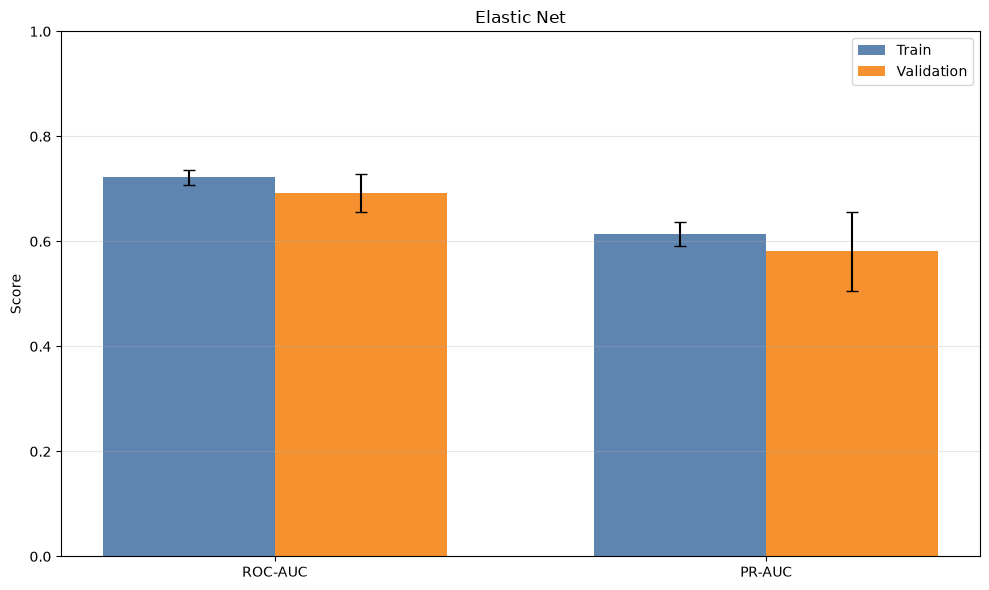

In [57]:
plot_internal_validation(
    cv_results_EN,
    metrics_list=['ROC-AUC', 'PR-AUC'],
    title="Elastic Net"
 )

Take a look at the relevant columns:

In [19]:
relevant_cols, irrelevant_cols = get_relevant_features(optimized_EN)

print("relevant features: ", relevant_cols)
print("\n")
print("irrelevant features: ", irrelevant_cols)

relevant features:  ['ERAF', 'score_baseaf2', 'AF_type', 'AF_duration', 'previous_ablation', 'stroke', 'sex', 'hypertension', 'age', 'intervention', 'score_chad2ds2_vasc', 'bundle_branch_R', 'OSA']


irrelevant features:  ['BMI', 'glucose', 'HDL', 'triglycerides', 'score_hatch', 'score_chads2', 'score_mblater', 'smoking_status', 'diabetes', 'hypercholesterolemia', 'renal_insuf', 'COPD', 'bundle_branch_L', 'cardiomyopathy', 'antirrythmic_meds', 'LA_enlargment', 'LVEF']


Drop irrelevant features from the data set:

In [20]:
if enable_filter:
    X_train_filtered = X_train.drop(columns=irrelevant_cols)
    X_test_filtered = X_test.drop(columns=irrelevant_cols)
else:
    X_train_filtered = X_train
    X_test_filtered = X_test

#### Support Vector Machine

Define the parameter distributions and set up the pipeline:

In [21]:
# Get preprocessor
preprocessor_SVM = get_full_preprocessor(X_train_filtered, seed=seed)

# Build the pipeline
pipe_SVM = Pipeline(steps=[
    ('preprocessor', preprocessor_SVM),
    ('clf', SVC(random_state=seed, max_iter=100000))
])

# Hyperparameters search space
params_dist_SVM = hyperparameters_search_space['SVM']

Train and optimize the model:

In [22]:
(
optimized_SVM, 
cv_results_SVM,
fpr_SVM, tpr_SVM,
precs_SVM, recs_SVM
) = optimize_model_random_search(
    pipeline=pipe_SVM, 
    param_distributions=params_dist_SVM, 
    X_train=X_train_filtered, y_train=y_train, 
    X_test=X_test_filtered, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 200 candidates, totalling 1000 fits


/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=100000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/conda/envs/tfm_python/lib/python3.11/site-packages/sklearn/

Performing internal cross-validation...
Performing external cross-validation...


Save the optimized model and check the hyperparameters:

In [23]:
save_model(fitted_pipeline=optimized_SVM, output_dir=results_path, identifier="SVM")

,Hyperparameter,Optimal Value
1,C,0.022438
2,break_ties,False
3,cache_size,200
4,coef0,0.0
5,decision_function_shape,ovr
6,degree,3
7,gamma,0.006866
8,kernel,sigmoid
9,max_iter,100000
10,probability,deprecated


Check the overfitting:

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'SVM'}, ylabel='Score'>,
     Metric     Dataset      mean       std
 0   PR-AUC       Train  0.599013  0.028935
 1   PR-AUC  Validation  0.575712  0.087272
 2  ROC-AUC       Train  0.712723  0.017374
 3  ROC-AUC  Validation  0.681902  0.044743)

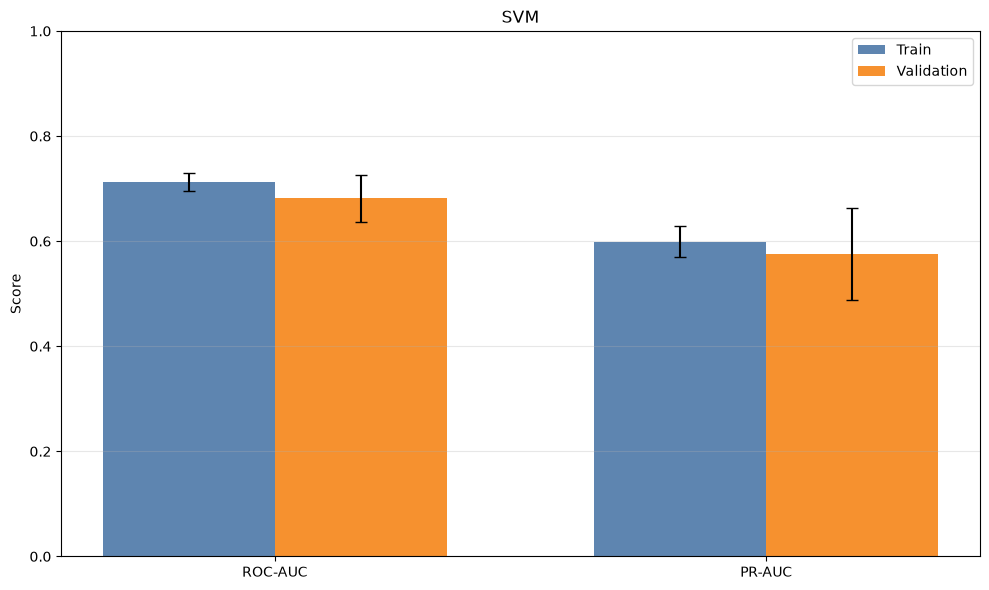

In [58]:
plot_internal_validation(
    cv_results_SVM,
    metrics_list=['ROC-AUC', 'PR-AUC'],
    title="SVM"
 )

#### Decision Tree

Define the parameter distributions and set up the pipeline:

In [25]:
# Get the preprocessor
preprocessor_DT = get_trees_preprocessor(X_train_filtered, seed=seed)

# Build the pipeline
pipe_DT = Pipeline(steps=[
    ('preprocessor', preprocessor_DT),
    ('clf', DecisionTreeClassifier(random_state=seed))
])

# Hyperparameters search space
params_dist_DT = hyperparameters_search_space['DT']


Train and optimize the model:

In [26]:
(
optimized_DT, 
cv_results_DT,
fpr_DT, tpr_DT,
precs_DT, recs_DT
) = optimize_model_random_search(
    pipeline=pipe_DT, 
    param_distributions=params_dist_DT, 
    X_train=X_train_filtered, y_train=y_train, 
    X_test=X_test_filtered, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Performing internal cross-validation...
Performing external cross-validation...


Save the optimized model and check the hyperparameters:

In [27]:
save_model(fitted_pipeline=optimized_DT, output_dir=results_path, identifier="DT")

,Hyperparameter,Optimal Value
1,ccp_alpha,0.0
2,criterion,entropy
3,max_depth,4
4,min_impurity_decrease,0.0
5,min_samples_leaf,18
6,min_samples_split,15
7,min_weight_fraction_leaf,0.0
8,random_state,7214
9,splitter,best


Check the overfitting:

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Decision Tree'}, ylabel='Score'>,
     Metric     Dataset      mean       std
 0   PR-AUC       Train  0.615019  0.015094
 1   PR-AUC  Validation  0.475523  0.038933
 2  ROC-AUC       Train  0.743822  0.009661
 3  ROC-AUC  Validation  0.611977  0.036430)

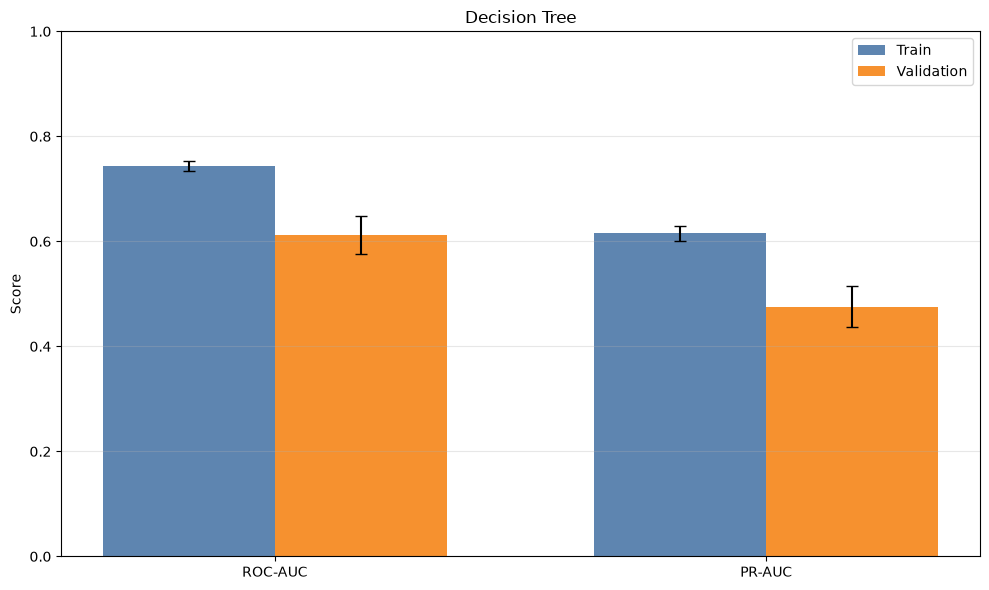

In [59]:
plot_internal_validation(
    cv_results_DT,
    metrics_list=['ROC-AUC', 'PR-AUC'],
    title="Decision Tree"
 )

#### Random Forest

Define the parameter distributions and set up the pipeline:

In [29]:
# Get the preprocessor
preprocessor_RF = get_trees_preprocessor(X_train_filtered, seed=seed)

# Build the pipeline
pipe_RF = Pipeline(steps=[
    ('preprocessor', preprocessor_RF),
    ('clf', RandomForestClassifier(random_state=seed))
])

# Hyperparameters search space
params_dist_RF = hyperparameters_search_space['RF']

Train and optimize the model:

In [30]:
(
optimized_RF, 
cv_results_RF,
fpr_RF, tpr_RF,
precs_RF, recs_RF
) = optimize_model_random_search(
    pipeline=pipe_RF, 
    param_distributions=params_dist_RF, 
    X_train=X_train_filtered, y_train=y_train, 
    X_test=X_test_filtered, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Performing internal cross-validation...
Performing external cross-validation...


Save the optimized model and check the hyperparameters:

In [31]:
save_model(fitted_pipeline=optimized_RF, output_dir=results_path, identifier="RF")

,Hyperparameter,Optimal Value
1,bootstrap,True
2,ccp_alpha,0.0
3,class_weight,balanced_subsample
4,criterion,gini
5,max_depth,2
6,min_impurity_decrease,0.0
7,min_samples_leaf,2
8,min_samples_split,7
9,min_weight_fraction_leaf,0.0
10,n_estimators,373


Check the overfitting:

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Random Forest'}, ylabel='Score'>,
     Metric     Dataset      mean       std
 0   PR-AUC       Train  0.670781  0.015822
 1   PR-AUC  Validation  0.587530  0.071821
 2  ROC-AUC       Train  0.756374  0.007529
 3  ROC-AUC  Validation  0.691072  0.027132)

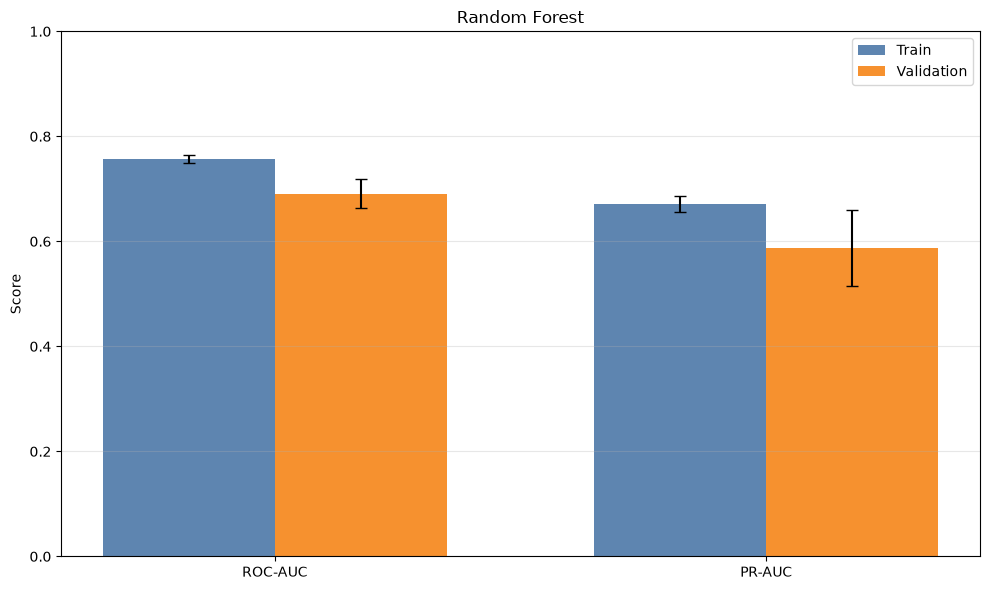

In [60]:
plot_internal_validation(
    cv_results_RF,
    metrics_list=['ROC-AUC', 'PR-AUC'],
    title="Random Forest"
 )

#### Extra Trees


Define the parameter distributions and set up the pipeline:


In [33]:
# Get the preprocessor
preprocessor_ET = get_trees_preprocessor(X_train_filtered, seed=seed)

# Build the pipeline
pipe_ET = Pipeline(steps=[
    ('preprocessor', preprocessor_ET),
    ('clf', ExtraTreesClassifier(random_state=seed))
])

# Hyperparameters search space
params_dist_ET = hyperparameters_search_space['RF']

Train and optimize the model:


In [34]:
(
optimized_ET, 
cv_results_ET,
fpr_ET, tpr_ET,
precs_ET, recs_ET
) = optimize_model_random_search(
    pipeline=pipe_ET, 
    param_distributions=params_dist_ET, 
    X_train=X_train_filtered, y_train=y_train, 
    X_test=X_test_filtered, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Performing internal cross-validation...
Performing external cross-validation...


Save the optimized model and check the hyperparameters:


In [35]:
save_model(fitted_pipeline=optimized_ET, output_dir=results_path, identifier="ET")


,Hyperparameter,Optimal Value
1,bootstrap,False
2,ccp_alpha,0.0
3,class_weight,balanced_subsample
4,criterion,gini
5,max_depth,4
6,max_features,0.6
7,min_impurity_decrease,0.0
8,min_samples_leaf,1
9,min_samples_split,13
10,min_weight_fraction_leaf,0.0


Check the overfitting:


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Extra Trees'}, ylabel='Score'>,
     Metric     Dataset      mean       std
 0   PR-AUC       Train  0.745921  0.011435
 1   PR-AUC  Validation  0.588463  0.071095
 2  ROC-AUC       Train  0.798393  0.001937
 3  ROC-AUC  Validation  0.669191  0.033415)

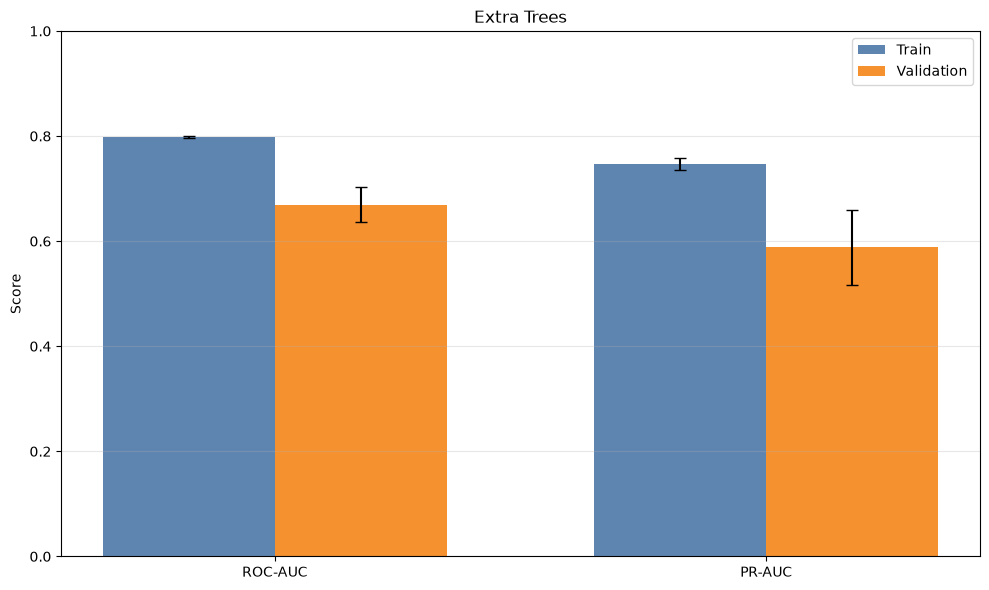

In [36]:
plot_internal_validation(
    cv_results_ET,
    metrics_list=['ROC-AUC', 'PR-AUC'],
    title="Extra Trees"
 )

#### Adaptative Boosting

Define the parameter distributions and set up the pipeline:

In [37]:
# Get the preprocessor
preprocessor_AB = get_trees_preprocessor(X_train_filtered, seed=seed)

# Build the pipeline
pipe_AB = Pipeline(steps=[
    ('preprocessor', preprocessor_AB),
    ('clf', AdaBoostClassifier(random_state=seed, 
                            estimator=DecisionTreeClassifier(random_state=seed)))
])

# Hyperparameters search space
params_dist_AB = hyperparameters_search_space['AB']


Train and optimize the model:

In [38]:
(
optimized_AB, 
cv_results_AB,
fpr_AB, tpr_AB,
precs_AB, recs_AB
) = optimize_model_random_search(
    pipeline=pipe_AB, 
    param_distributions=params_dist_AB, 
    X_train=X_train_filtered, y_train=y_train, 
    X_test=X_test_filtered, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Performing internal cross-validation...
Performing external cross-validation...


Save the optimized model and check the hyperparameters:

In [39]:
save_model(fitted_pipeline=optimized_AB, output_dir=results_path, identifier="AB")

,Hyperparameter,Optimal Value
1,estimator__ccp_alpha,0.0
2,estimator__criterion,gini
3,estimator__max_depth,2
4,estimator__max_features,sqrt
5,estimator__min_impurity_decrease,0.0
6,estimator__min_samples_leaf,1
7,estimator__min_samples_split,20
8,estimator__min_weight_fraction_leaf,0.0
9,estimator__random_state,7214
10,estimator__splitter,best


Check the overfitting:

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Extra Trees'}, ylabel='Score'>,
     Metric     Dataset      mean       std
 0   PR-AUC       Train  0.745921  0.011435
 1   PR-AUC  Validation  0.588463  0.071095
 2  ROC-AUC       Train  0.798393  0.001937
 3  ROC-AUC  Validation  0.669191  0.033415)

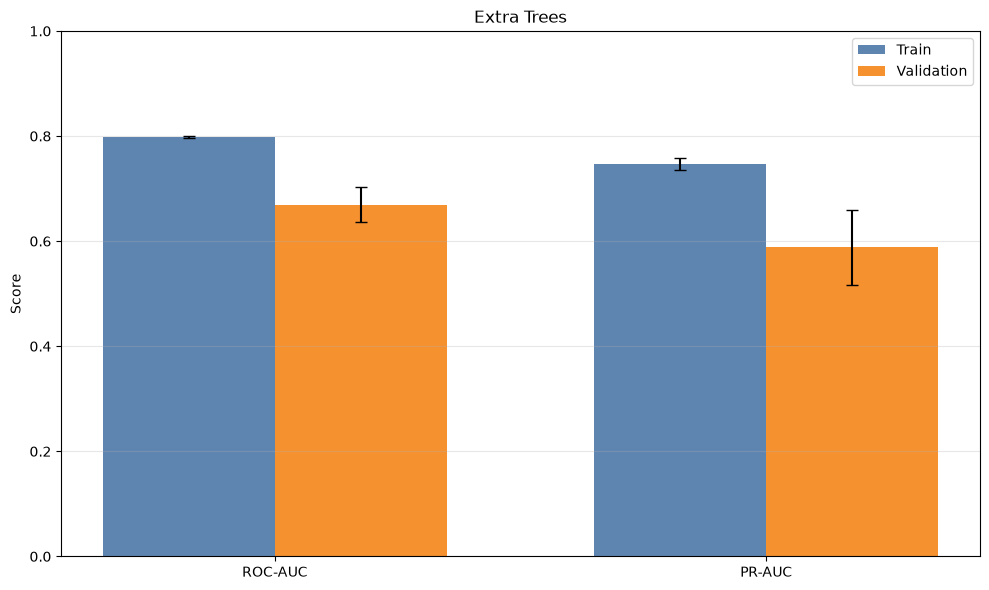

In [40]:
plot_internal_validation(
    cv_results_ET,
    metrics_list=['ROC-AUC', 'PR-AUC'],
    title="Extra Trees"
 )

#### Gradient Boosting

Define the parameter distributions and set up the pipeline:

In [41]:
# Get the preprocessor
preprocessor_GB = get_trees_preprocessor(X_train_filtered, seed=seed)

# Build the pipeline
pipe_GB = Pipeline(steps=[
    ('preprocessor', preprocessor_GB),
    ('clf', GradientBoostingClassifier(random_state=seed ))
])

# Hyperparameters search space
params_dist_GB = hyperparameters_search_space['GB']

Train and optimize the model:

In [42]:
(
optimized_GB, 
cv_results_GB,
fpr_GB, tpr_GB,
precs_GB, recs_GB
) = optimize_model_random_search(
    pipeline=pipe_GB, 
    param_distributions=params_dist_GB, 
    X_train=X_train_filtered, y_train=y_train, 
    X_test=X_test_filtered, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Performing internal cross-validation...
Performing external cross-validation...


Save the optimized model and check the hyperparameters:

In [43]:
save_model(fitted_pipeline=optimized_GB, output_dir=results_path, identifier="GB")

,Hyperparameter,Optimal Value
1,ccp_alpha,0.0
2,criterion,deprecated
3,learning_rate,0.003597
4,loss,log_loss
5,max_depth,2
6,max_features,0.6
7,min_impurity_decrease,0.0
8,min_samples_leaf,2
9,min_samples_split,9
10,min_weight_fraction_leaf,0.0


Check the overfitting:

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Gradient Boosting'}, ylabel='Score'>,
     Metric     Dataset      mean       std
 0   PR-AUC       Train  0.681947  0.014281
 1   PR-AUC  Validation  0.590620  0.079664
 2  ROC-AUC       Train  0.766270  0.011741
 3  ROC-AUC  Validation  0.695935  0.034617)

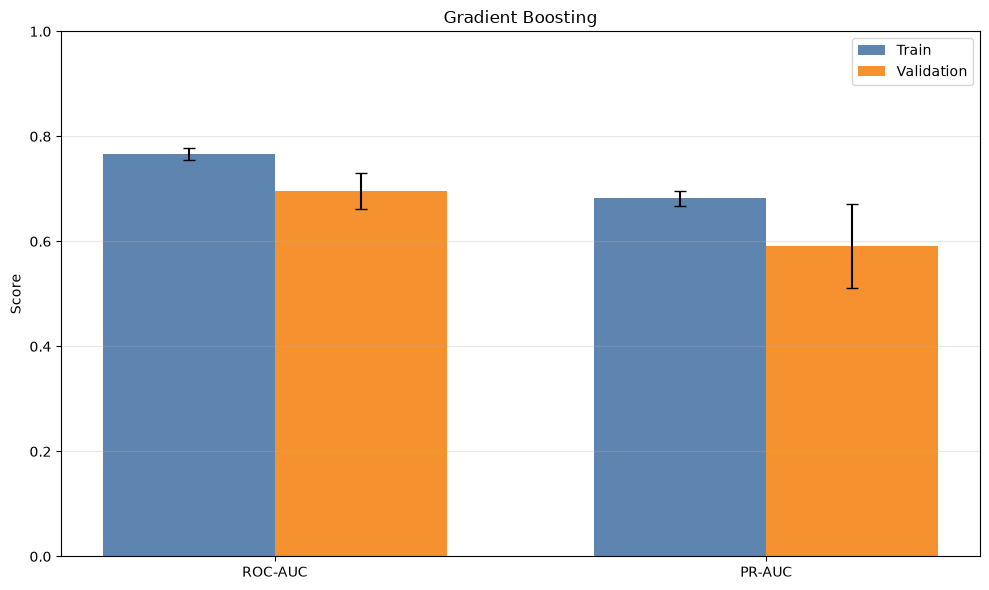

In [44]:
plot_internal_validation(
    cv_results_GB,
    metrics_list=['ROC-AUC', 'PR-AUC'],
    title="Gradient Boosting"
 )

#### Multi-Layer Perceptron

Define the parameter distributions and set up the pipeline:

In [45]:
# Get the preprocessor
preprocessor_MLP = get_full_preprocessor(X_train_filtered, seed=seed)

# Full pipeline
pipe_MLP = Pipeline(steps=[
    ('preprocessor', preprocessor_MLP),
    ('clf', MLPClassifier(random_state=seed, max_iter=1000, early_stopping=True, validation_fraction=0.1))
])

# Hyperparameters search space
params_dist_MLP = hyperparameters_search_space['MLP']

Train and optimize the model:

In [46]:
(
optimized_MLP, 
cv_results_MLP,
fpr_MLP, tpr_MLP,
precs_MLP, recs_MLP
) = optimize_model_random_search(
    pipeline=pipe_MLP, 
    param_distributions=params_dist_MLP, 
    X_train=X_train_filtered, y_train=y_train, 
    X_test=X_test_filtered, y_test=y_test, 
    metrics_dict=scoring_dict, 
    cv=my_cv,
    n_iter=n_trials,
    seed=seed
    )

Starting randomized hyperparameter optimization...
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Performing internal cross-validation...
Performing external cross-validation...


Save the optimized model and check the hyperparameters:

In [47]:
save_model(fitted_pipeline=optimized_MLP, output_dir=results_path, identifier="MLP")


,Hyperparameter,Optimal Value
1,activation,tanh
2,alpha,0.074355
3,batch_size,4
4,beta_1,0.9
5,beta_2,0.999
6,early_stopping,True
7,epsilon,0.0
8,hidden_layer_sizes,"(100, 50)"
9,learning_rate,constant
10,learning_rate_init,0.004803


Check the overfitting:

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Multi-Layer Perceptron'}, ylabel='Score'>,
     Metric     Dataset      mean       std
 0   PR-AUC       Train  0.620701  0.028210
 1   PR-AUC  Validation  0.581510  0.076788
 2  ROC-AUC       Train  0.726351  0.016154
 3  ROC-AUC  Validation  0.675555  0.049351)

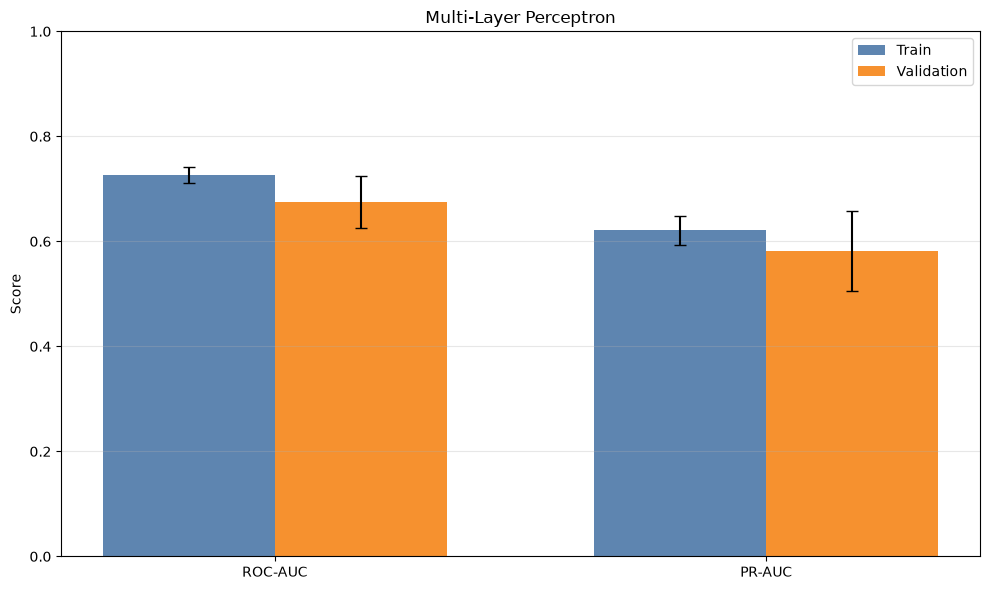

In [48]:
plot_internal_validation(
    cv_results_MLP,
    metrics_list=['ROC-AUC', 'PR-AUC'],
    title="Multi-Layer Perceptron"
 )

## Save results

In [62]:
models = ["Elastic Net", "SVM", "Decision Tree", "Random Forest", "Extra Trees", "AdaBoost", "Gradient Boost", "MLP"]

models_dict = {
    "Elastic Net": cv_results_EN,
    "SVM": cv_results_SVM,
    "Decision Tree": cv_results_DT,
    "Random Forest": cv_results_RF,
    "Extra Trees": cv_results_ET,
    "AdaBoost": cv_results_AB,
    "Gradient Boost": cv_results_GB,
    "MLP": cv_results_MLP
}


### Main metrics

In [63]:
results_df = save_metrics_results(models_dict=models_dict, output_dir=results_path)

results_df.head()

,Model,Metric,Dataset,Score
0,Elastic Net,ROC-AUC,Train,0.734075
1,Elastic Net,ROC-AUC,Validation,0.661519
2,Elastic Net,ROC-AUC,Train,0.733220
3,Elastic Net,ROC-AUC,Validation,0.666117
4,Elastic Net,ROC-AUC,Train,0.710518


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'PR-AUC by model'}, xlabel='PR-AUC', ylabel='Model'>,
             Model     Score
 2     Elastic Net  0.592030
 5             MLP  0.575659
 7             SVM  0.542456
 0        AdaBoost  0.534094
 3     Extra Trees  0.533700
 4  Gradient Boost  0.514375
 6   Random Forest  0.507941
 1   Decision Tree  0.482127)

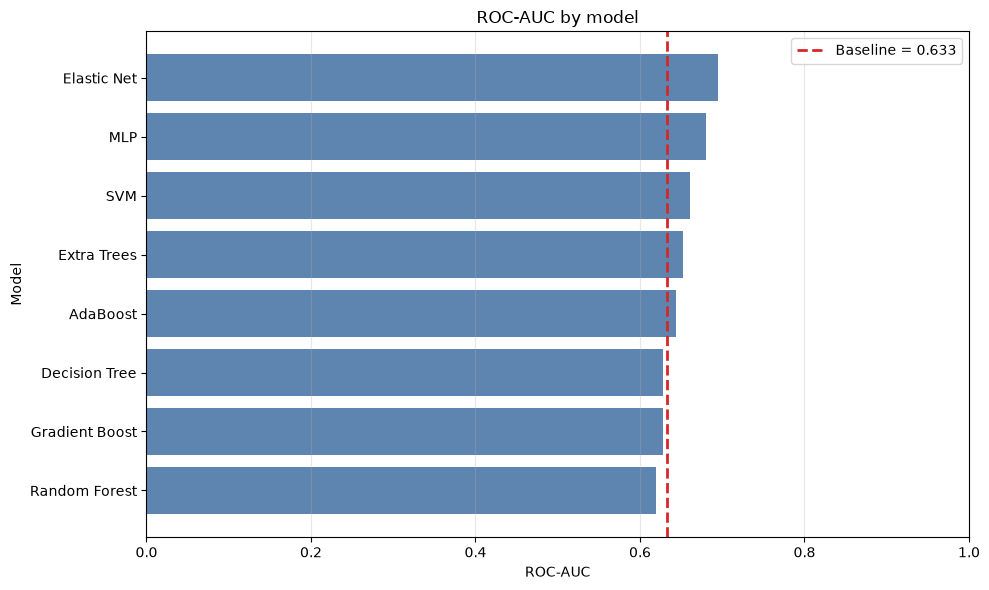

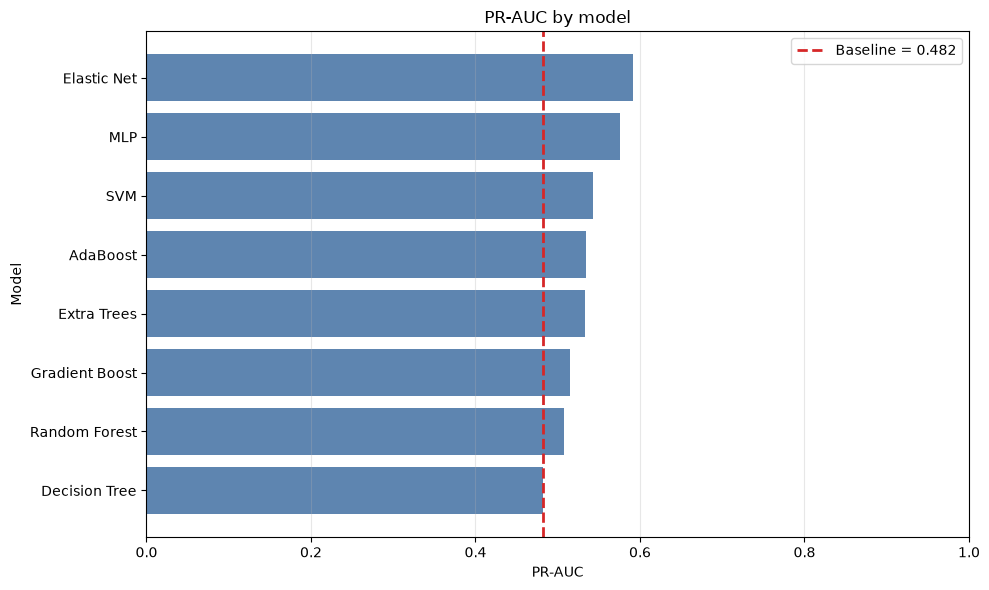

In [64]:
roc_auc_baseline = 0.633
pr_auc_baseline = 0.482

plot_external_validation(
    results_df,
    baseline=roc_auc_baseline,
    metric='ROC-AUC',
    title='ROC-AUC by model'
 )

plot_external_validation(
    results_df,
    baseline=pr_auc_baseline,
    metric='PR-AUC',
    title='PR-AUC by model'
 )

### ROC and PR curves

Join the metrics into a csv file:

In [65]:
# Save the false/true positive rates values into a csv
fpr = [fpr_EN, fpr_SVM, fpr_DT, fpr_RF, fpr_ET, fpr_AB, fpr_GB, fpr_MLP]
tpr = [tpr_EN, tpr_SVM, tpr_DT, tpr_RF, tpr_ET, tpr_AB, tpr_GB, tpr_MLP]

roc_results = save_curves_results(models, fpr, tpr, curve_type='roc', 
                                output_dir=results_path)

# Save the precision and recall values for the PR curves into a csv
precs = [precs_EN, precs_SVM, precs_DT, precs_RF, precs_ET, precs_AB, precs_GB, precs_MLP]
recs = [recs_EN, recs_SVM, recs_DT, recs_RF, recs_ET, recs_AB, recs_GB, recs_MLP]

pr_results = save_curves_results(models, recs, precs, curve_type='pr', 
                                output_dir=results_path)


Plot ROC curves:

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'ROC curves'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>)

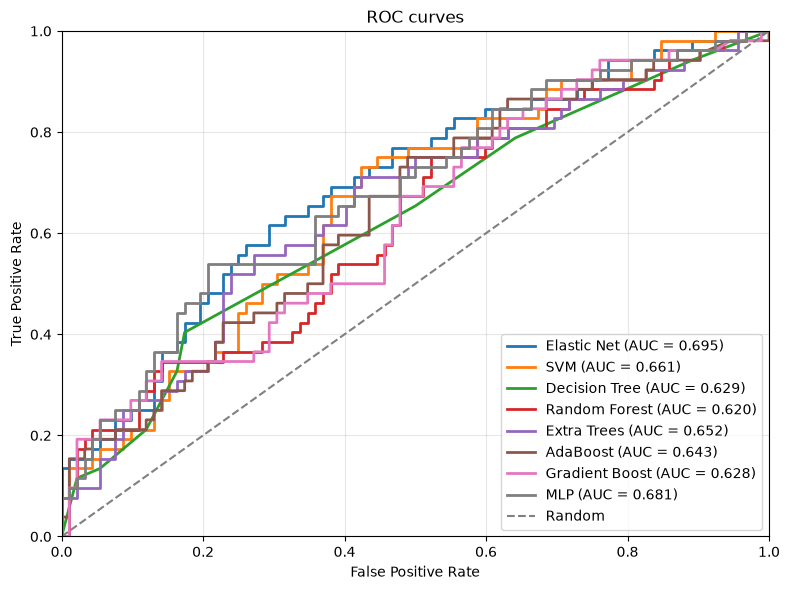

In [67]:
plot_roc_curves(
    roc_results,
    title='ROC curves'
 )

Plot PR curves:

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Precision-Recall curves'}, xlabel='Recall', ylabel='Precision'>)

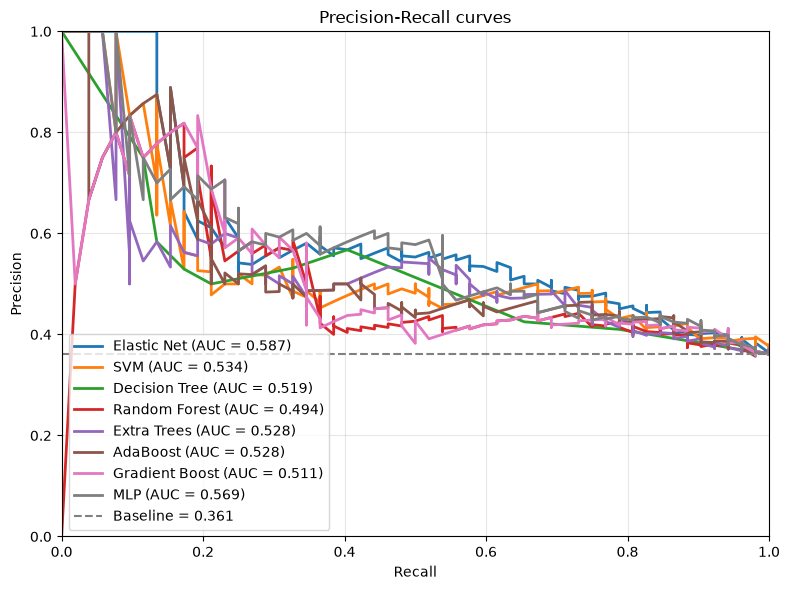

In [68]:
test_prevalence = y_test.astype(float).mean()

plot_pr_curves(
    pr_results,
    baseline=test_prevalence,
    title='Precision-Recall curves'
 )